In [6]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
class GradientBoostClassifier:
    def __init__(self,n_estimators=100,max_depth=5,learning_rate=1.0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.lr = learning_rate
        self.trees = []
        self.leafs = []
        self.f0 = None

    def fit(self,x_train,y_train):
        # f0:
        p1 = np.mean(y_train)
        p0 = 1 - p1
        self.f0 = np.log(p1/p0)

        current_preds = np.full(len(y_train),self.f0)
        for _ in range(self.n_estimators):
            # probability:
            probs = self._sigmoid(current_preds)
            # pseudo-residuals:
            residuals = y_train - probs
            # fitting a tree on x_train and residuals:
            tree = DecisionTreeRegressor(max_depth=self.max_depth,random_state=42)
            tree.fit(x_train,residuals)

            # getting leaf values:
            leaf_ids = tree.apply(x_train)
            leaf_values = {}

            for leaf in np.unique(leaf_ids):
                rows = np.where(leaf_ids==leaf)[0]
                # calculating the log(odds):
                num = residuals[rows].sum()
                den = (probs[rows]*(1-probs[rows])).sum()
                if den == 0:
                    leaf_value = 0
                else:
                    leaf_value = num/den

                leaf_values[leaf] = leaf_value
                # updarting the predictions:
            for i in range(len(current_preds)):
                current_preds[i] += self.lr*leaf_values[leaf_ids[i]]

            self.trees.append(tree)
            self.leafs.append(leaf_values)

    def predict(self,x_test):
        preds = np.full(len(x_test),self.f0)

        for tree,leaf_values in zip(self.trees,self.leafs):
            leaf_ids = tree.apply(x_test)

            for i in range(len(x_test)):
                preds[i] += self.lr*leaf_values[leaf_ids[i]]

        probs = self._sigmoid(preds)

        predictions = (probs >= 0.5).astype(int)

        return predictions

    def _sigmoid(self,X):
        return 1/(1 + np.exp(-X))

In [15]:
def plot_decision_boundary(model, X, y, resolution=0.02):
    # Define the mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution)
    )

    # Predict on every point in the grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)

    # Reshape predictions
    Z = Z.reshape(xx.shape)

    # Plot decision regions
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.35)

    # Plot training points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="k",
        s=50
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Gradient Boosting Decision Boundary")
    plt.show()

In [5]:
x, y = make_moons(
    n_samples=500,
    noise=0.4,
    random_state=42
)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

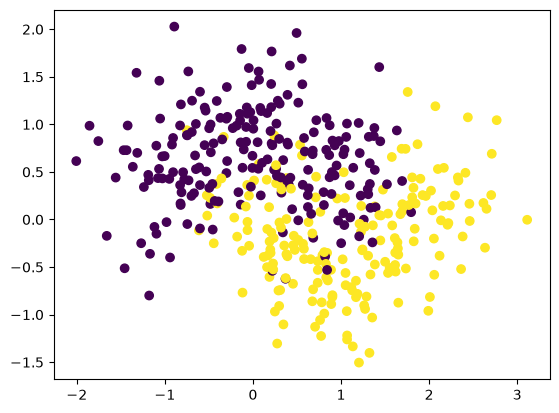

In [7]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)

In [13]:
gbc = GradientBoostClassifier(max_depth=1)
gbc.fit(x_train,y_train)

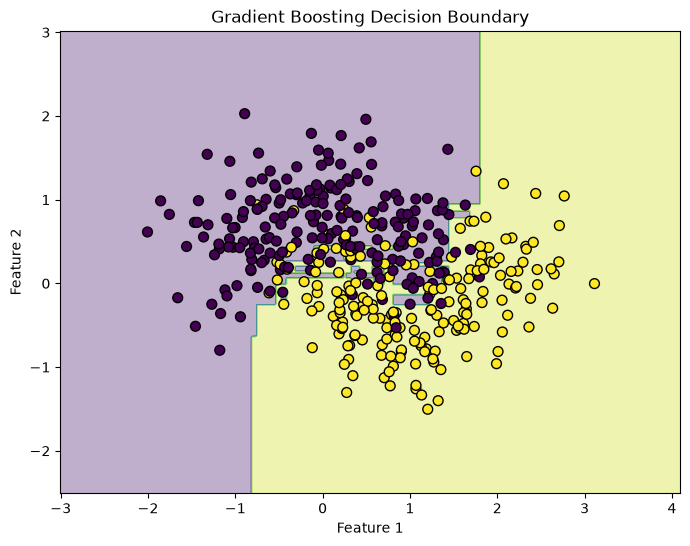

In [16]:
plot_decision_boundary(gbc,x_train,y_train)

In [17]:
accuracy_score(y_test,gbc.predict(x_test))

0.8